# Baseline Models — Thai Food Recommendation Engine
**Group:** Flower | **Authors:** Ton (st127004) · Sam (st127012)

This notebook establishes two baselines on the **RIRD (English, labelled)** dataset:

| # | Model | Description |
|---|---|---|
| 1 | **BM25** | Lexical keyword-matching baseline (no GPU, no training) |
| 2 | **Dense (no fusion)** | Mean-pooled multilingual sentence embeddings per restaurant |

Both are evaluated with the **same harness** (`eval_utils.py`) so any future fusion variant
can be added in one cell and appear in the same comparison table.

**Metrics:** MAP · MRR · nDCG@5 · nDCG@10 · Recall@5 · Recall@10 · P@5 · P@10  
**Labels:** binary (`If only Low or High`) + graded (annotator vote sum 0–5) for nDCG


## 0. Setup & Imports

In [1]:
import sys, re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

# Resolve project root for Colab environment
HERE = Path.cwd() # This is typically /content/ in Colab
ROOT = HERE # Make ROOT point to /content/ directly
DATA = HERE # Make DATA also point to /content/ since files are read directly from there

# Ensure the directory containing eval_utils.py is in sys.path
sys.path.insert(0, str(ROOT)) # Add /content/ to the path

from eval_utils import evaluate_model, compare_models

print('ROOT :', ROOT)
print('DATA :', DATA)

ROOT : /content
DATA : /content


## 1. Data Loading

Two RIRD files:
- `reviews/50_restaurants_all_rates.csv` — 29 k reviews across 50 restaurants
- `PMD.csv` — 100 queries × 50 restaurants, 5 annotators each


In [2]:
# ── Reviews ─────────────────────────────────────────────────────────────────
rev = pd.read_csv('/content/50_restaurants_all_rates.csv')
rev['review_text'] = rev['review_text'].fillna('').astype(str)
print(f"Reviews: {rev.shape}  |  unique restaurants: {rev['business_id'].nunique()}")
rev.head(2)


Reviews: (29168, 9)  |  unique restaurants: 50


,Unnamed: 0.1,Unnamed: 0,business_id,user_id,review_stars,review_text,name,categories,date
0,0,10537,DE89UdHFMCN6DtYWZuer5A,Cqe3kUtSdFXc7YTA4jYAtg,3.0,Bit of a wait at the door. No problem. Spicy k...,Hokkaido Ramen Santouka,"Ramen, Noodles",2019-01-20
1,1,10538,DE89UdHFMCN6DtYWZuer5A,NtfB0Aq8puw0Hpetewc0FQ,4.0,"Not sure why, but the shoyu broth and noodle h...",Hokkaido Ramen Santouka,"Ramen, Noodles",2018-10-27


In [3]:
# ── PMD ─────────────────────────────────────────────────────────────────────
pmd_raw = pd.read_csv('/content/PMD.csv')
pmd = pmd_raw.drop_duplicates().copy()
print(f'PMD rows after dedup: {len(pmd)}  (was {len(pmd_raw)})')

ANNOTATORS = ['Annotator1','Annotator2','Annotator3','Annotator4','Annotator5']
AGG_COL    = 'If only Low or  High'   # note: double space — actual column name in PMD.csv

# Cast annotator columns and AGG_COL to int (they may load as float due to NaN)
for col in ANNOTATORS + [AGG_COL]:
    pmd[col] = pd.to_numeric(pmd[col], errors='coerce').fillna(0).astype(int)

print('PMD columns:', pmd.columns.tolist())
pmd.head(3)


PMD rows after dedup: 5000  (was 5001)
PMD columns: ['Restaurant name', 'query', 'Annotator1', 'Annotator2', 'Annotator3', 'Annotator4', 'Annotator5', 'If only Low or  High']


,Restaurant name,query,Annotator1,Annotator2,Annotator3,Annotator4,Annotator5,If only Low or High
0,Ding Tai Fung,Can I have a cheat meal?,0,0,0,0,1,0
1,Ding Tai Fung,I feel chubby and need to lose weight,0,0,0,0,1,0
2,Ding Tai Fung,I want to have a crazy night with my friends,0,0,0,0,0,0


## 2. Build Ground Truth (qrels)

| Name | Type | Used for |
|---|---|---|
| `binary_qrels` | `{query -> set of relevant business_ids}` | MAP, MRR, Recall, P |
| `graded_qrels` | `{query -> {business_id -> annotator_vote_sum (0–5)}}` | graded nDCG |


In [4]:
# Map restaurant name → business_id via the reviews table
# (reviews uses column 'name'; PMD uses 'Restaurant name')
name_to_bid = (
    rev.drop_duplicates('business_id')
       .set_index('name')['business_id']
       .to_dict()
)

# Identify the restaurant column in PMD — actual column is 'Restaurant name'
name_col = next(
    (c for c in ['Restaurant name', 'restaurant_name', 'name', 'business_id']
     if c in pmd.columns),
    None
)
print(f'Restaurant identifier column in PMD: {name_col!r}')
print(f'Sample names in PMD : {pmd[name_col].unique()[:5].tolist()}')
print(f'Sample names in rev : {list(name_to_bid.keys())[:5]}')


Restaurant identifier column in PMD: 'Restaurant name'
Sample names in PMD : ['Ding Tai Fung', 'Dragon Boat Fusion Cuisine', 'Dumpling House Restaurant', 'Eggspectation', 'Fat Ninja Bite']
Sample names in rev : ['Hokkaido Ramen Santouka', 'Beerbistro', 'Muncheez', 'Dragon Boat Fusion Cuisine', 'JaBistro']


In [5]:
binary_qrels: dict = {}
graded_qrels: dict = {}

for query, grp in pmd.groupby('query'):
    rel_set   = set()
    rel_grade = {}
    for _, row in grp.iterrows():
        restaurant = row[name_col]
        bid   = name_to_bid.get(restaurant, restaurant)
        grade = int(sum(row[a] for a in ANNOTATORS if pd.notna(row[a])))
        if row[AGG_COL] == 1:
            rel_set.add(bid)
        rel_grade[bid] = grade
    binary_qrels[query] = rel_set
    graded_qrels[query] = rel_grade

n_queries = len(binary_qrels)
avg_pos   = np.mean([len(v) for v in binary_qrels.values()])
print(f'Queries: {n_queries}  |  avg relevant restaurants/query: {avg_pos:.1f}')


Queries: 100  |  avg relevant restaurants/query: 13.5


## 3. BM25 Baseline

**Strategy:** concatenate all reviews per restaurant into one document,
tokenise (lowercase + strip punctuation), build a BM25Okapi index, score all 50
restaurants per query, rank by score.

BM25 is the standard lexical baseline used in the ECIR 2023 RIR paper.


In [6]:
!pip install rank-bm25

In [7]:
from rank_bm25 import BM25Okapi

def simple_tokenise(text: str):
    return re.sub(r'[^a-z0-9\s]', ' ', text.lower()).split()

# One document per restaurant (all reviews concatenated)
restaurant_docs = (
    rev.groupby('business_id')['review_text']
       .apply(lambda texts: ' '.join(texts))
       .reset_index()
)

corpus_ids   = restaurant_docs['business_id'].tolist()
corpus_texts = [simple_tokenise(t) for t in restaurant_docs['review_text']]

bm25 = BM25Okapi(corpus_texts)
print(f'BM25 index built over {len(corpus_ids)} restaurants')


BM25 index built over 50 restaurants


In [8]:
bm25_rankings: dict = {}

for query in tqdm(binary_qrels.keys(), desc='BM25 queries'):
    q_tokens = simple_tokenise(query)
    scores   = bm25.get_scores(q_tokens)
    ranked   = [corpus_ids[i] for i in np.argsort(scores)[::-1]]
    bm25_rankings[query] = ranked

print('BM25 ranking complete')


BM25 queries: 100%|██████████| 100/100 [00:00<00:00, 2186.02it/s]

BM25 ranking complete


In [9]:
bm25_results = evaluate_model(
    rankings     = bm25_rankings,
    binary_qrels = binary_qrels,
    graded_qrels = graded_qrels,
)

print('BM25 Results:')
for metric, val in bm25_results.items():
    print(f'  {metric:<12} {val:.4f}')


BM25 Results:
  MAP          0.5612
  MRR          0.7690
  nDCG@5       0.6008
  Recall@5     0.3156
  P@5          0.4620
  nDCG@10      0.6211
  Recall@10    0.4501
  P@10         0.4070


## 4. Dense Baseline — Mean-Pooled Embeddings (No Fusion)

**Strategy:** encode every review with a multilingual sentence transformer,
mean-pool all embeddings per restaurant → one vector, then rank by cosine
similarity to the query embedding.

This isolates the contribution of the fusion step — everything else is
identical to the proposed model.

> **Note:** encoding 29 k reviews takes ~10–20 min on CPU. No caching applied here.


In [10]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
embedder   = SentenceTransformer(MODEL_NAME)
print(f'Loaded: {MODEL_NAME}')


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded: sentence-transformers/paraphrase-multilingual-mpnet-base-v2


In [11]:
# Encode all reviews (one embedding per review, no sentence splitting here)
all_texts = rev['review_text'].tolist()
all_bids  = rev['business_id'].tolist()

print(f'Encoding {len(all_texts):,} reviews...')
all_embeddings = embedder.encode(
    all_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f'Embeddings shape: {all_embeddings.shape}')


Encoding 29,168 reviews...


Batches:   0%|          | 0/456 [00:00<?, ?it/s]

Embeddings shape: (29168, 768)


In [12]:
# Mean-pool per restaurant → one vector per restaurant
restaurant_embs = {}
for bid in set(all_bids):
    idxs = [i for i, b in enumerate(all_bids) if b == bid]
    restaurant_embs[bid] = all_embeddings[idxs].mean(axis=0)

bid_list    = list(restaurant_embs.keys())
rest_matrix = np.stack([restaurant_embs[b] for b in bid_list])  # (50, D)
print(f'Restaurant embedding matrix: {rest_matrix.shape}')


Restaurant embedding matrix: (50, 768)


In [13]:
# Encode all queries then rank
queries      = list(binary_qrels.keys())
q_embeddings = embedder.encode(queries, show_progress_bar=True, convert_to_numpy=True)

dense_rankings: dict = {}
for query, q_emb in tqdm(zip(queries, q_embeddings), total=len(queries), desc='Dense ranking'):
    sims   = cosine_similarity(q_emb.reshape(1, -1), rest_matrix)[0]
    ranked = [bid_list[i] for i in np.argsort(sims)[::-1]]
    dense_rankings[query] = ranked

print('Dense ranking complete')


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Dense ranking: 100%|██████████| 100/100 [00:00<00:00, 1838.01it/s]

Dense ranking complete


In [14]:
dense_results = evaluate_model(
    rankings     = dense_rankings,
    binary_qrels = binary_qrels,
    graded_qrels = graded_qrels,
)

print('Dense (no fusion) Results:')
for metric, val in dense_results.items():
    print(f'  {metric:<12} {val:.4f}')


Dense (no fusion) Results:
  MAP          0.5880
  MRR          0.7701
  nDCG@5       0.6287
  Recall@5     0.3485
  P@5          0.5220
  nDCG@10      0.6448
  Recall@10    0.4758
  P@10         0.4450


## 5. Cross-Model Comparison

Add any new model to `all_results` below — it will appear in the table and plot
automatically. Future fusion variants (max-pool, top-k mean, weighted sum) go here.


In [15]:
# ── Register all models here ─────────────────────────────────────────────────
# Pattern: 'Model Name' : results_dict from evaluate_model()
all_results = {
    'BM25'             : bm25_results,
    'Dense (no fusion)': dense_results,
    # 'Max Fusion'     : max_results,       # ← fusion variants go here
    # 'Top-3 Mean'     : top3_results,
    # 'Weighted Sum'   : weighted_results,
}

comparison_df = compare_models(all_results)
print('\n=== Cross-Model Comparison (RIRD) ===')
comparison_df



=== Cross-Model Comparison (RIRD) ===


,MAP,MRR,nDCG@5,Recall@5,P@5,nDCG@10,Recall@10,P@10
Model,,,,,,,,
BM25,0.5612,0.7690,0.6008,0.3156,0.462,0.6211,0.4501,0.407
Dense (no fusion),0.5880,0.7701,0.6287,0.3485,0.522,0.6448,0.4758,0.445


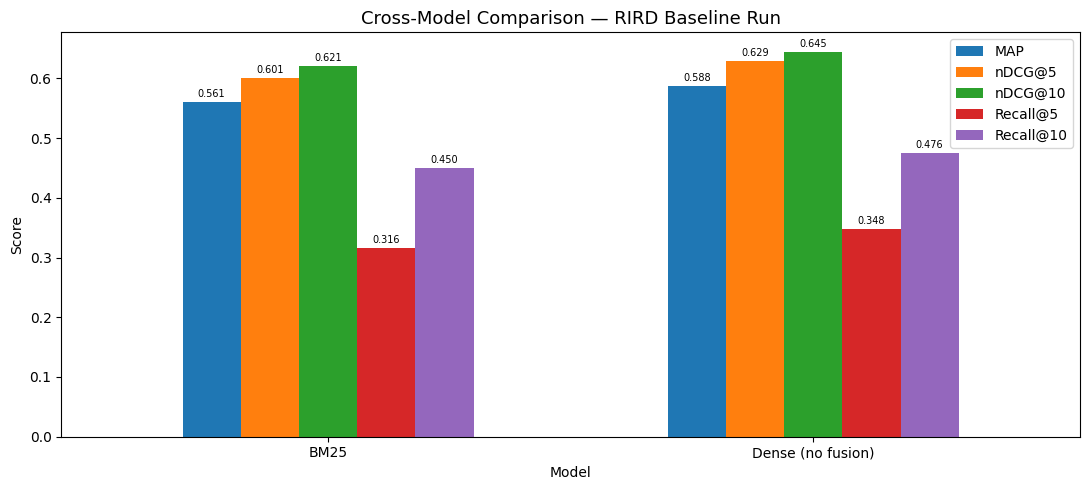

In [16]:
import matplotlib.pyplot as plt

metrics_to_plot = ['MAP', 'nDCG@5', 'nDCG@10', 'Recall@5', 'Recall@10']
plot_df = comparison_df[metrics_to_plot]

ax = plot_df.plot(kind='bar', figsize=(11, 5), rot=0, width=0.6)
ax.set_title('Cross-Model Comparison — RIRD Baseline Run', fontsize=13)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.legend(loc='upper right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()
